### *Import Library*

In [1]:
import os
import cv2
import numpy as np
import pyfeats
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, auc
)

### *Preprocessing Data*

In [2]:
# =============================================
# Preprocessing Data (Grayscale, Resize, CLAHE)
# =============================================
input_dirs = {
    'Normal': 'C:/SKRIPSI/Dataset/NORMAL',
    'Pneumonia': 'C:/SKRIPSI/Dataset/PNEUMONIA'
}
label_map = {'Normal': 0, 'Pneumonia': 1}

processed_images = []
labels = []

for label, folder in input_dirs.items():
    for fname in tqdm(os.listdir(folder), desc=f"Preprocessing {label}"):
        if fname.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img)
            processed_images.append(img)
            labels.append(label_map[label])

Preprocessing Pneumonia: 100%|██████████| 1000/1000 [00:11<00:00, 89.52it/s]


### *Ekstraksi Fitur*

In [3]:
# ===============================
# Ekstraksi Fitur GLCM
# ===============================
glcm_list = []
for img in tqdm(processed_images, desc="Ekstraksi GLCM"):
    glcm = pyfeats.glcm_features(img)
    combined = np.concatenate([glcm[0], glcm[1]])
    drop = [i for i in [12, 13, 14, 20, 26, 27, 28] if i < len(combined)]
    glcm_filtered = np.delete(combined, drop)
    glcm_list.append(glcm_filtered)

glcm_df = pd.DataFrame(glcm_list, columns=[
    'GLCM_ASM_Mean', 'GLCM_Contrast_Mean', 'GLCM_Correlation_Mean', 'GLCM_SumOfSquaresVariance_Mean',
    'GLCM_InverseDifferenceMoment_Mean', 'GLCM_SumAverage_Mean', 'GLCM_SumVariance_Mean', 'GLCM_SumEntropy_Mean',
    'GLCM_Entropy_Mean', 'GLCM_DifferenceVariance_Mean', 'GLCM_DifferenceEntropy_Mean',
    'GLCM_ASM_Range', 'GLCM_Contrast_Range', 'GLCM_Correlation_Range', 'GLCM_SumOfSquaresVariance_Range',
    'GLCM_InverseDifferenceMoment_Range', 'GLCM_SumAverage_Range', 'GLCM_SumVariance_Range', 'GLCM_SumEntropy_Range',
    'GLCM_Entropy_Range', 'GLCM_DifferenceVariance_Range', 'GLCM_DifferenceEntropy_Range'])
glcm_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi GLCM selesai")
# # print(glcm_df.head())

# glcm_df.to_csv("fitur_glcm.csv", index=False)

Ekstraksi GLCM:   0%|          | 0/2000 [00:00<?, ?it/s]

Ekstraksi GLCM: 100%|██████████| 2000/2000 [03:54<00:00,  8.54it/s]


### *Feature removal*

In [5]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from scipy.stats import zscore
import joblib

# ===== Custom Transformer =====
class ZScoreMasking(BaseEstimator, TransformerMixin):
    def __init__(self, mask=None):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.mask is None:
            return X
        return X[:, self.mask]

# ===== Load Dataset =====
# Pastikan 'glcm_df' sudah didefinisikan sebelumnya (DataFrame dengan fitur + kolom 'Label')
X = glcm_df.drop(columns=['Label']).values
y = glcm_df['Label'].values
feature_names = glcm_df.drop(columns=['Label']).columns

print("\n📊 Jumlah fitur awal:", X.shape[1])

# ===== Hitung Statistik Z-Score dan Varians =====
z = np.abs(zscore(X))
mean_z = z.mean(axis=0)
var = X.var(axis=0)

print("\n🔍 Statistik per fitur:")
for i, name in enumerate(feature_names):
    print(f"  {name:35} | mean_z: {mean_z[i]:.4f} | var: {var[i]:.6f}")

# ===== Grid Threshold Setup =====
thresh_range = np.arange(0.5, 4.5, 0.25)
param_grid = []
mask_dict = {}

for t in thresh_range:
    mask = (mean_z < t) & (var > 1e-5)
    selected = np.where(mask)[0]

    # Hapus fitur dengan korelasi tinggi (>0.95)
    if len(selected) > 1:
        corr = np.corrcoef(X[:, selected].T)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                if abs(corr[i, j]) > 0.95:
                    if mean_z[selected[i]] > mean_z[selected[j]]:
                        mask[selected[i]] = False
                    else:
                        mask[selected[j]] = False

    # ⛔ Skip jika hasil akhir tidak menyisakan fitur
    if mask.sum() < 1:
        print(f"📌 Threshold: {t:.2f} | ❌ Semua fitur terfilter.")
        continue

    mask_dict[t] = mask
    print(f"📌 Threshold: {t:.2f} | ✅ Fitur tersisa: {mask.sum()}")

    param_grid.append({
        'mask__mask': [mask],
        'svc__C': [0.1, 1.0, 10.0]
    })

# Validasi: apakah ada konfigurasi valid?
if not param_grid:
    raise ValueError("❌ Tidak ada konfigurasi threshold yang menghasilkan minimal 1 fitur.")

# ===== Build Pipeline =====
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mask', ZScoreMasking()),
    ('svc', LinearSVC(max_iter=100000, dual=False))
])

# ===== GridSearch =====
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

# ===== Ambil Kombinasi dengan Fitur < Penuh =====
results = grid.cv_results_
filtered = [
    (i, params['mask__mask'])
    for i, params in enumerate(results['params'])
    if params['mask__mask'].sum() < X.shape[1]
]

if filtered:
    # Ambil skor tertinggi dari konfigurasi yang menyusutkan fitur
    best_i, best_mask = max(
        filtered,
        key=lambda x: results['mean_test_score'][x[0]]
    )
    best_threshold = [
        t for t, m in mask_dict.items() if np.array_equal(m, best_mask)
    ][0]
    final_model = grid.best_estimator_
else:
    # Fallback: semua fitur terpilih → pakai hasil terbaik GridSearch
    best_mask = grid.best_params_['mask__mask']
    best_threshold = [
        t for t, m in mask_dict.items() if np.array_equal(m, best_mask)
    ][0]
    final_model = grid.best_estimator_

X_filtered = X[:, best_mask]

# ===== Output Hasil =====
print("\n✅ Threshold terbaik:", best_threshold)
print("📊 Jumlah fitur sebelum masking:", X.shape[1])
print("✅ Jumlah fitur setelah masking:", X_filtered.shape[1])
print("✅ Fitur yang dipertahankan:", feature_names[best_mask].tolist())

# (Opsional) Simpan model
# joblib.dump(final_model, 'best_model.pkl')



📊 Jumlah fitur awal: 22

🔍 Statistik per fitur:
  GLCM_ASM_Mean                       | mean_z: 0.6950 | var: 0.000046
  GLCM_Contrast_Mean                  | mean_z: 0.7997 | var: 10770.017962
  GLCM_Correlation_Mean               | mean_z: 0.7623 | var: 0.000158
  GLCM_SumOfSquaresVariance_Mean      | mean_z: 0.8087 | var: 874785.430710
  GLCM_InverseDifferenceMoment_Mean   | mean_z: 0.7751 | var: 0.001541
  GLCM_SumAverage_Mean                | mean_z: 0.7686 | var: 595.119151
  GLCM_SumVariance_Mean               | mean_z: 0.8075 | var: 13633751.419115
  GLCM_SumEntropy_Mean                | mean_z: 0.7645 | var: 0.041443
  GLCM_Entropy_Mean                   | mean_z: 0.7718 | var: 0.197706
  GLCM_DifferenceVariance_Mean        | mean_z: 0.7751 | var: 0.000000
  GLCM_DifferenceEntropy_Mean         | mean_z: 0.8147 | var: 0.078030
  GLCM_ASM_Range                      | mean_z: 0.7847 | var: 0.000823
  GLCM_Contrast_Range                 | mean_z: 0.7374 | var: 2903.466231
  GLCM_

### *Normalisasi*

In [6]:
# ===============================
# ⚙️ 6. Split & Normalisasi
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### *Modeling*

Fitting 5 folds for each of 55 candidates, totalling 275 fits

✅ Parameter Terbaik: {'C': 10.0, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
✅ Akurasi CV Terbaik: 0.9306
✅ Akurasi pada data uji: 0.9300

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93       200
   Pneumonia       0.94      0.92      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



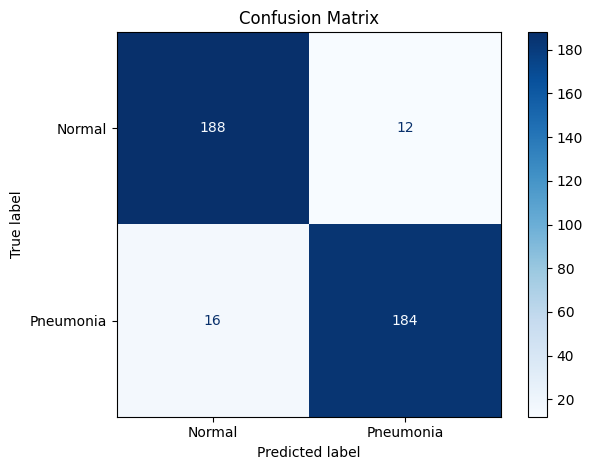

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# ------------------------
# Parameter Grid SVM
# ------------------------
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'class_weight': ['balanced']
    }
]

# ------------------------
# Grid Search CV
# ------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

# ------------------------
# Tampilkan hasil terbaik
# ------------------------
print("\n✅ Parameter Terbaik:", grid.best_params_)
print(f"✅ Akurasi CV Terbaik: {grid.best_score_:.4f}")

# ------------------------
# Evaluasi di Test Data
# ------------------------
model = grid.best_estimator_
test_acc = model.score(X_test_scaled, y_test)
print(f"✅ Akurasi pada data uji: {test_acc:.4f}")

y_pred = model.predict(X_test_scaled)

# Tambahkan label_names
label_names = list(label_map.keys())  # Fix error di sini

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# ============================
# 📉 Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### *CV Result*

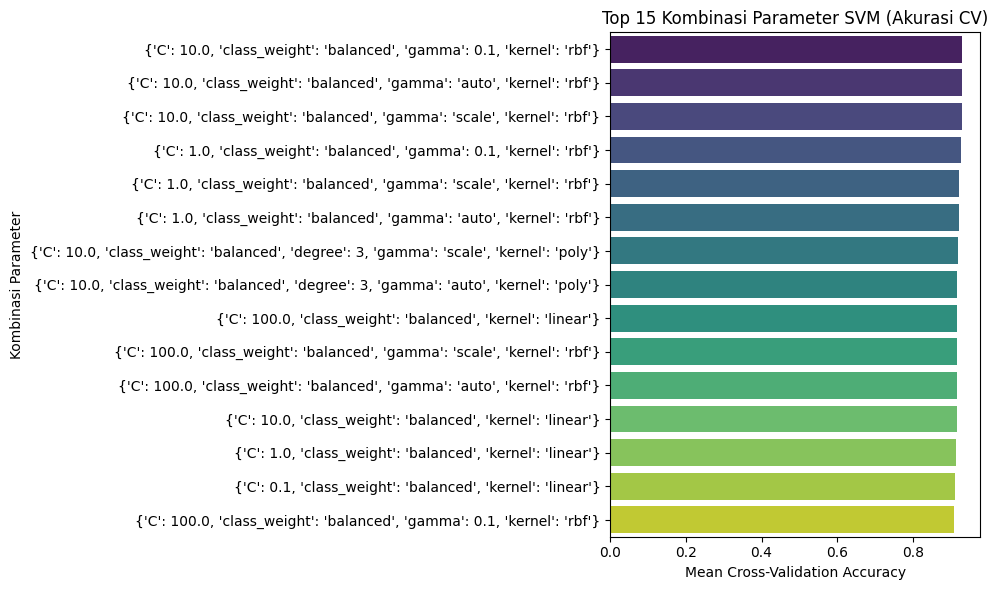

In [8]:
import seaborn as sns

# Ambil hasil grid search dalam DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# Gabungkan parameter menjadi string
cv_results["params_str"] = cv_results["params"].astype(str)

# Urutkan berdasarkan skor tertinggi
top_cv = cv_results.sort_values(by="mean_test_score", ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cv, x="mean_test_score", y="params_str", hue="params_str", dodge=False, palette="viridis", legend=False)
plt.title("Top 15 Kombinasi Parameter SVM (Akurasi CV)")
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Kombinasi Parameter")
plt.tight_layout()
plt.show()


### *Classification Report Matrix*

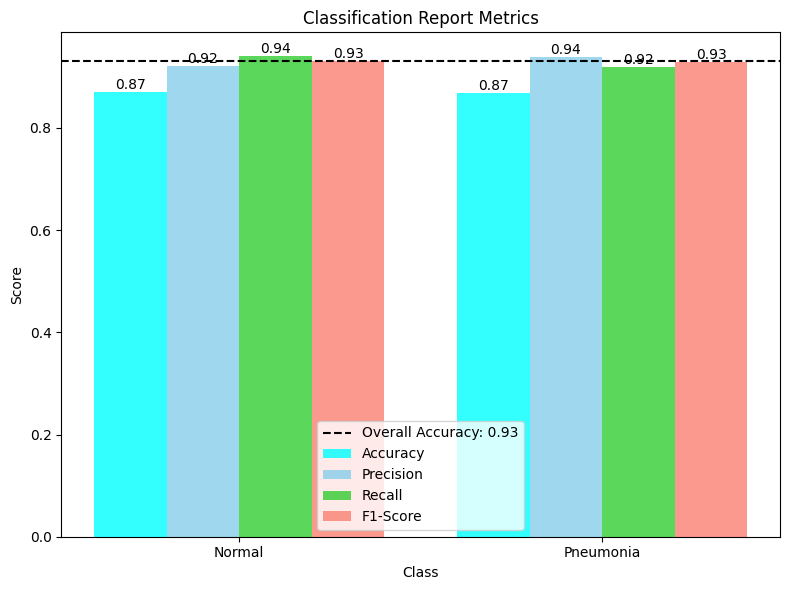


📊 Akurasi per kelas:
Kelas Normal: 0.87
Kelas Pneumonia: 0.87
📊 Precision: [0.92156863 0.93877551]
📊 Recall: [0.94 0.92]
📊 F1-Score: [0.93069307 0.92929293]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Pastikan y_test hanya berisi dua kelas (misalnya 0 dan 1)
unique_classes = np.unique(y_test)
if len(unique_classes) != 2:
    raise ValueError("y_test harus berisi hanya dua kelas untuk klasifikasi biner. Gunakan multiclass jika lebih dari dua kelas.")

# Hitung prediksi
y_pred = model.predict(X_test_scaled)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

# Hitung akurasi per kelas
accuracy_per_class = []
for i in range(len(unique_classes)):
    tp = cm[i, i]
    fp = sum(cm[:, i]) - tp
    fn = sum(cm[i, :]) - tp
    acc_class = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    accuracy_per_class.append(acc_class)

# Hitung precision, recall, dan f1-score untuk kedua kelas
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None, labels=unique_classes)
accuracy = model.score(X_test_scaled, y_test)

# Data untuk grafik
classes = ['Normal', 'Pneumonia']  
accuracy_values = accuracy_per_class
precision_values = precision
recall_values = recall
f1_score_values = f1

# Plot grafik batang
fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.2
index = np.arange(len(classes))

bars1 = ax.bar(index, accuracy_values, bar_width, label='Accuracy', color='cyan', alpha=0.8)
bars2 = ax.bar(index + bar_width, precision_values, bar_width, label='Precision', color='skyblue', alpha=0.8)
bars3 = ax.bar(index + 2 * bar_width, recall_values, bar_width, label='Recall', color='limegreen', alpha=0.8)
bars4 = ax.bar(index + 3 * bar_width, f1_score_values, bar_width, label='F1-Score', color='salmon', alpha=0.8)

# Garis dashed untuk rata-rata accuracy
ax.axhline(y=accuracy, color='black', linestyle='--', label=f'Overall Accuracy: {accuracy:.2f}')

# Label dan judul
ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Classification Report Metrics')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(classes)
ax.legend()

# Tambahkan nilai di atas batang
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n📊 Akurasi per kelas:")
for i, class_name in enumerate(classes):
    print(f"Kelas {class_name}: {accuracy_per_class[i]:.2f}")
print(f"📊 Precision: {precision}")
print(f"📊 Recall: {recall}")
print(f"📊 F1-Score: {f1}")

### *AUC*

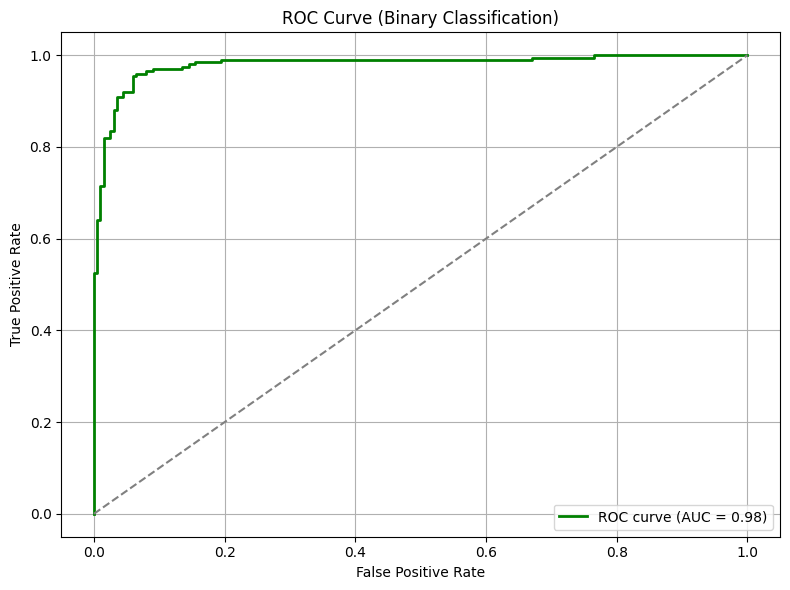

In [10]:
from sklearn.metrics import roc_curve, auc

# ROC Curve (untuk klasifikasi biner)
y_test_bin = label_binarize(y_test, classes=[0, 1]).ravel()
y_score = model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### *Save Model*

In [11]:
# # Simpan model dan tools
joblib.dump(model, 'model_svm.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(best_mask, 'best_mask_glcm.pkl')
print("\nModel dan file preprocessing berhasil disimpan!")


Model dan file preprocessing berhasil disimpan!
